In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DB_PATH = "../../03_DATABASE/oasst.db"

conn = sqlite3.connect(DB_PATH)

print("SQLite database connected successfully!")

SQLite database connected successfully!


In [2]:
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

tables

,name
0,conversations
1,messages


In [3]:
df = pd.read_sql_query(
    "SELECT * FROM messages",
    conn
)

print("Rows   :", len(df))
print("Columns:", len(df.columns))

df.head()

Rows   : 88838
Columns: 18


,message_id,message_tree_id,parent_id,user_id,created_date,text,role,lang,review_count,review_result,deleted,rank,synthetic,detoxify,tree_state,emojis,labels,source_split
0,6ab24d72-0181-4594-a9cd-deaf170242fb,6ab24d72-0181-4594-a9cd-deaf170242fb,None,c3fe8c76-fc30-4fa7-b7f8-c492f5967d18,2023-02-05T14:23:50.983374+0000,Can you write a short introduction about the r...,prompter,en,3,1.0,0,NaN,0,"{'toxicity': 0.00044308538781479, 'severe_toxi...",ready_for_export,"{'name': array(['+1', '_skip_reply', '_skip_ra...","{'name': array(['spam', 'lang_mismatch', 'pii'...",train
1,c8e83833-ecbc-44fe-b6db-735228c25a1c,6ab24d72-0181-4594-a9cd-deaf170242fb,6ab24d72-0181-4594-a9cd-deaf170242fb,2c96e467-66f0-4be7-9693-bda51356a424,2023-02-06T13:50:44.657083+0000,"""Monopsony"" refers to a market structure where...",assistant,en,3,1.0,0,0.0,0,"{'toxicity': 0.00026396565954200923, 'severe_t...",ready_for_export,"{'name': array(['+1', '_skip_labeling'], dtype...","{'name': array(['spam', 'fails_task', 'lang_mi...",train
2,6708c47f-05c9-4346-b3d2-40b2bd24fde4,6ab24d72-0181-4594-a9cd-deaf170242fb,c8e83833-ecbc-44fe-b6db-735228c25a1c,2c96e467-66f0-4be7-9693-bda51356a424,2023-02-06T18:48:49.391686+0000,Now explain it to a dog,prompter,en,3,1.0,0,NaN,0,"{'toxicity': 0.03648477792739868, 'severe_toxi...",ready_for_export,None,"{'name': array(['spam', 'lang_mismatch', 'pii'...",train
3,343ee2d4-87ae-41fd-a768-bdd65959dc4a,6ab24d72-0181-4594-a9cd-deaf170242fb,6ab24d72-0181-4594-a9cd-deaf170242fb,49ddcb0d-6588-43bd-858d-19c577f12e7b,2023-02-06T13:37:56.044680+0000,Monopsony is a market structure in which there...,assistant,en,3,1.0,0,1.0,0,"{'toxicity': 0.0008866374846547842, 'severe_to...",ready_for_export,"{'name': array(['+1', '_skip_reply', '_skip_la...","{'name': array(['spam', 'fails_task', 'lang_mi...",train
4,18145bf4-37fd-4ac0-80f5-6108b5f2b365,6ab24d72-0181-4594-a9cd-deaf170242fb,343ee2d4-87ae-41fd-a768-bdd65959dc4a,e10e99a0-38ac-4b07-bf5d-4427696e4e0d,2023-02-06T18:52:51.428543+0000,How can one fight back when a monospony had be...,prompter,en,3,1.0,0,NaN,0,"{'toxicity': 0.0009362137061543763, 'severe_to...",ready_for_export,"{'name': array(['+1'], dtype=object), 'count':...","{'name': array(['spam', 'lang_mismatch', 'pii'...",train


In [4]:
df.info()
df.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88838 entries, 0 to 88837
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   message_id       88838 non-null  object 
 1   message_tree_id  88838 non-null  object 
 2   parent_id        78474 non-null  object 
 3   user_id          88838 non-null  object 
 4   created_date     88838 non-null  object 
 5   text             88838 non-null  object 
 6   role             88838 non-null  object 
 7   lang             88838 non-null  object 
 8   review_count     88838 non-null  int64  
 9   review_result    88106 non-null  float64
 10  deleted          88838 non-null  int64  
 11  rank             51263 non-null  float64
 12  synthetic        88838 non-null  int64  
 13  detoxify         76093 non-null  object 
 14  tree_state       88838 non-null  object 
 15  emojis           75315 non-null  object 
 16  labels           88590 non-null  object 
 17  source_split

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
message_id,88838,88838,6ab24d72-0181-4594-a9cd-deaf170242fb,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
message_tree_id,88838,10364,cf7df6fd-a77d-4699-9f6a-5f16df055b35,56,NaN,NaN,NaN,NaN,NaN,NaN,NaN
parent_id,78474,42555,aa51deaf-dff1-4a4b-924f-76f4aa2594d5,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_id,88838,13249,df411b83-5030-4708-bf81-0fe9fa1398b2,1406,NaN,NaN,NaN,NaN,NaN,NaN,NaN
created_date,88838,88838,2023-02-05T14:23:50.983374+0000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
text,88838,87854,你好,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN
role,88838,2,assistant,55668,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lang,88838,25,en,41305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_count,88838.0,NaN,NaN,NaN,3.027545,0.323824,0.0,3.0,3.0,3.0,12.0
review_result,88106.0,NaN,NaN,NaN,0.984859,0.122114,0.0,1.0,1.0,1.0,1.0


In [5]:
missing = df.isnull().sum().sort_values(ascending=False)

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_percentage": (missing / len(df) * 100).round(2)
})

missing_df

,missing_count,missing_percentage
rank,37575,42.30
emojis,13523,15.22
detoxify,12745,14.35
parent_id,10364,11.67
review_result,732,0.82
labels,248,0.28
message_tree_id,0,0.00
message_id,0,0.00
created_date,0,0.00
user_id,0,0.00


In [6]:
role_analysis = (
    df["role"]
    .value_counts()
    .reset_index()
)

role_analysis.columns = ["role", "message_count"]

role_analysis

,role,message_count
0,assistant,55668
1,prompter,33170


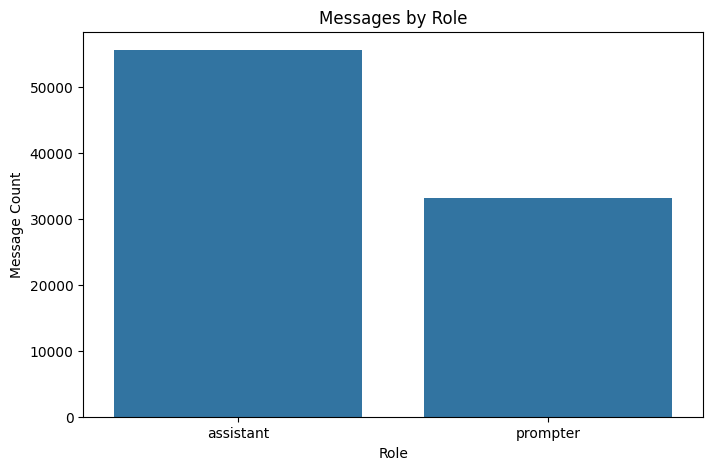

In [7]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=role_analysis,
    x="role",
    y="message_count"
)

plt.title("Messages by Role")
plt.xlabel("Role")
plt.ylabel("Message Count")
plt.show()

In [8]:
language_analysis = (
    df["lang"]
    .value_counts()
    .head(15)
    .reset_index()
)

language_analysis.columns = ["language", "message_count"]

language_analysis

,language,message_count
0,en,41305
1,es,23975
2,ru,7611
3,zh,3448
4,de,3195
5,fr,2653
6,th,1560
7,ca,1238
8,pt-BR,1203
9,uk-UA,640


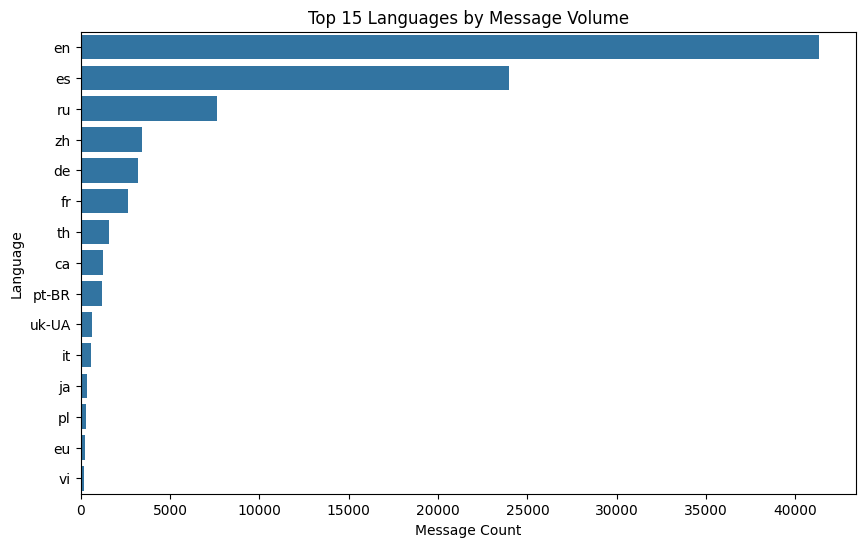

In [9]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=language_analysis,
    x="message_count",
    y="language"
)

plt.title("Top 15 Languages by Message Volume")
plt.xlabel("Message Count")
plt.ylabel("Language")
plt.show()

In [10]:
conversation_analysis = (
    df.groupby("message_tree_id")
      .size()
      .reset_index(name="message_count")
)

conversation_analysis.describe()

,message_count
count,10364.000000
mean,8.571787
std,4.428832
min,2.000000
25%,4.000000
50%,9.000000
75%,12.000000
max,56.000000


In [11]:
review_analysis = (
    df.groupby("review_result", dropna=False)
      .size()
      .reset_index(name="message_count")
)

review_analysis

,review_result,message_count
0,0.0,1334
1,1.0,86772
2,NaN,732


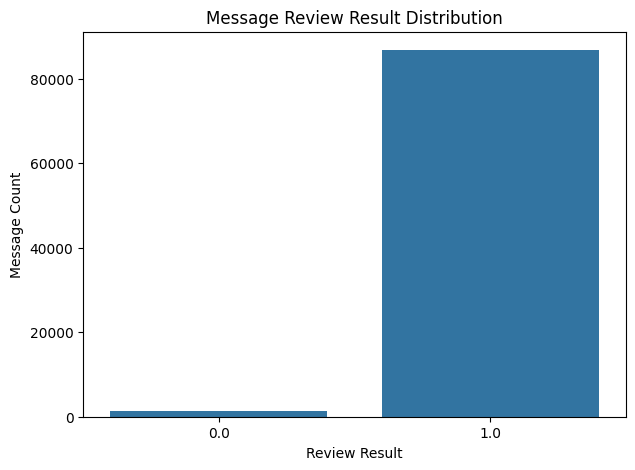

In [12]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=review_analysis,
    x="review_result",
    y="message_count"
)

plt.title("Message Review Result Distribution")
plt.xlabel("Review Result")
plt.ylabel("Message Count")
plt.show()

In [13]:
df["created_date"] = pd.to_datetime(
    df["created_date"],
    errors="coerce"
)

df["year_month"] = df["created_date"].dt.to_period("M").astype(str)

C:\Users\rehan khan\AppData\Local\Temp\ipykernel_19324\4048584353.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["year_month"] = df["created_date"].dt.to_period("M").astype(str)


In [14]:
monthly_messages = (
    df.groupby("year_month")
      .size()
      .reset_index(name="message_count")
)

monthly_messages

,year_month,message_count
0,2023-01,3206
1,2023-02,60932
2,2023-03,16479
3,2023-04,8221


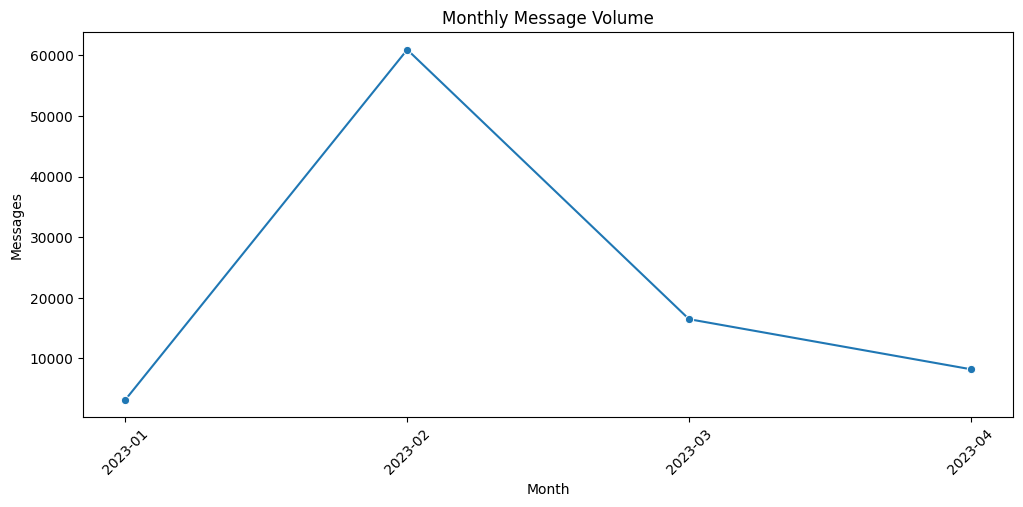

In [15]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_messages,
    x="year_month",
    y="message_count",
    marker="o"
)

plt.title("Monthly Message Volume")
plt.xlabel("Month")
plt.ylabel("Messages")
plt.xticks(rotation=45)
plt.show()

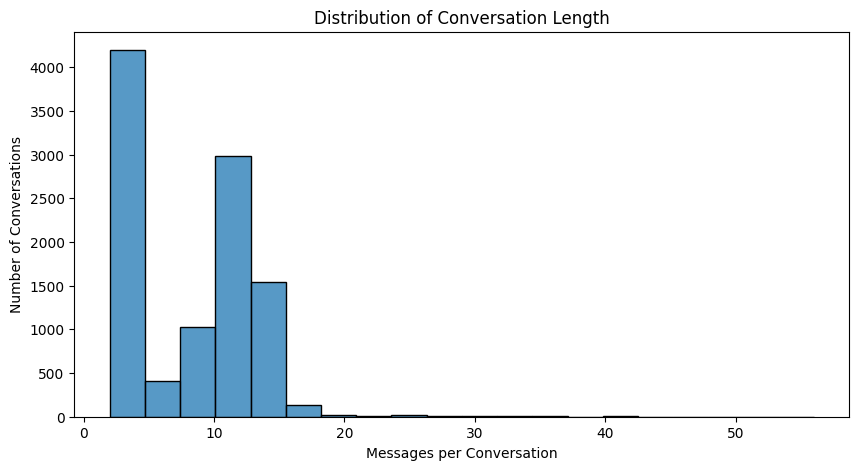

In [ ]:
conversation_length = (
    df.groupby("message_tree_id")
      .size()
      .reset_index(name="message_count")
)

plt.figure(figsize=(10, 5))

sns.histplot(
    conversation_length["message_count"],
    bins=20
)

plt.title("Distribution of Conversation Length")
plt.xlabel("Messages per Conversation")
plt.ylabel("Number of Conversations")

plt.show()

In [17]:
deleted_analysis = (
    df["deleted"]
    .value_counts()
    .reset_index()
)

deleted_analysis.columns = ["deleted", "message_count"]

deleted_analysis


,deleted,message_count
0,0,87285
1,1,1553


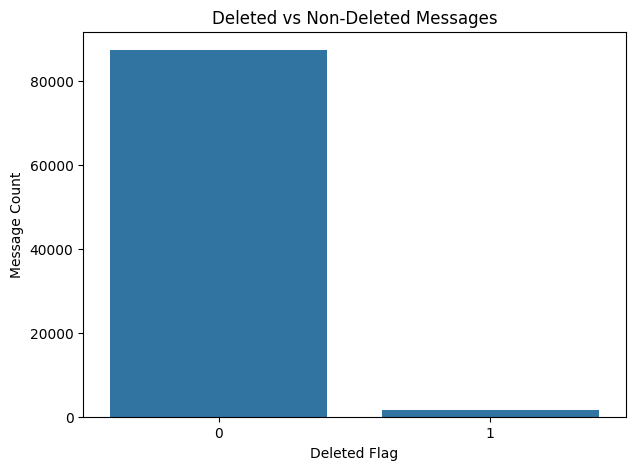

In [18]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=deleted_analysis,
    x="deleted",
    y="message_count"
)

plt.title("Deleted vs Non-Deleted Messages")
plt.xlabel("Deleted Flag")
plt.ylabel("Message Count")

plt.show()

In [19]:
language_role = (
    df.groupby(["lang", "role"])
      .size()
      .reset_index(name="message_count")
)

top_languages = (
    df["lang"]
    .value_counts()
    .head(10)
    .index
)

language_role_top = language_role[
    language_role["lang"].isin(top_languages)
]

language_role_top

,lang,role,message_count
3,ca,assistant,852
4,ca,prompter,386
9,de,assistant,1923
10,de,prompter,1272
11,en,assistant,25326
12,en,prompter,15979
13,es,assistant,16111
14,es,prompter,7864
19,fr,assistant,1594
20,fr,prompter,1059


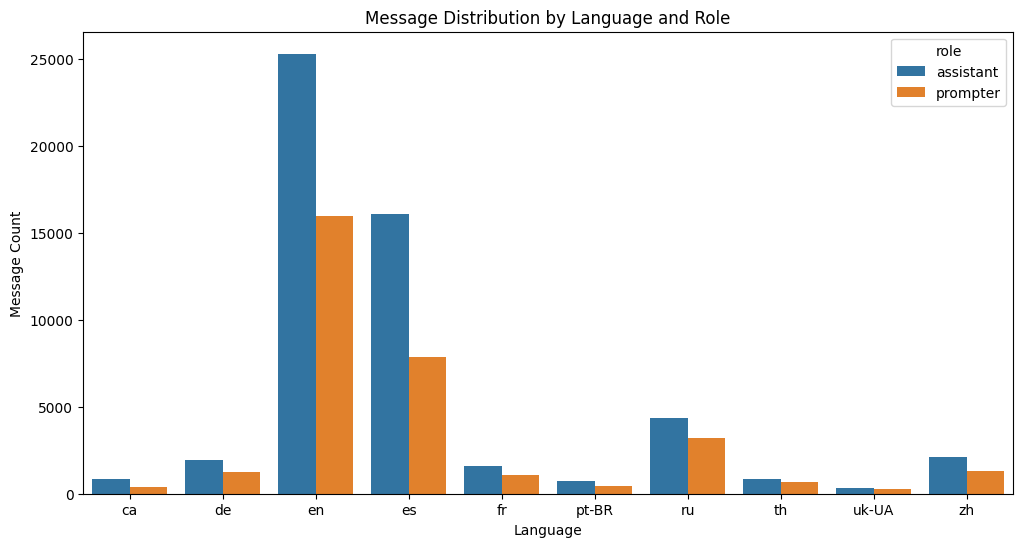

In [20]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=language_role_top,
    x="lang",
    y="message_count",
    hue="role"
)

plt.title("Message Distribution by Language and Role")
plt.xlabel("Language")
plt.ylabel("Message Count")

plt.show()

In [21]:
user_activity = (
    df.groupby("user_id")
      .size()
      .reset_index(name="message_count")
      .sort_values("message_count", ascending=False)
      .head(15)
)

user_activity

,user_id,message_count
11605,df411b83-5030-4708-bf81-0fe9fa1398b2,1406
2325,2d40e94c-40ed-4e00-a66e-454c0401c8ad,1295
9959,bf6867fd-6273-4ed3-99d9-5078e8c59b8a,1048
8507,a41f23d1-dc75-497d-8d99-a5b7b061022f,852
7837,97894afc-2204-4c7b-9b91-f1c71c10f032,842
1398,1aaa9be1-0d07-4cb2-a2d7-4301cbfc4ecc,750
346,068951d1-4a1e-4d91-9c29-0090fdf9366d,726
1317,18d2e4e9-ecbf-4bdf-918d-233b84cec2d4,647
11129,d65280b2-d787-4f2f-b469-4c14b509b2c3,537
8886,abbc8a37-2db7-4af5-9df1-b0582d2e3d93,524


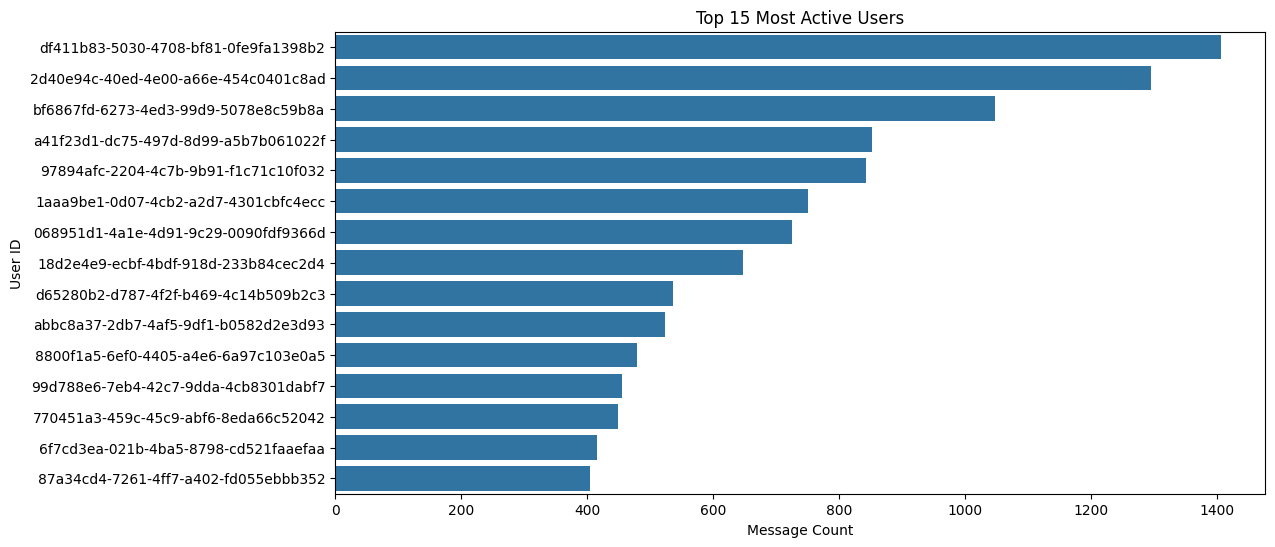

In [22]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=user_activity,
    x="message_count",
    y="user_id"
)

plt.title("Top 15 Most Active Users")
plt.xlabel("Message Count")
plt.ylabel("User ID")

plt.show()

In [23]:
review_role = (
    df.assign(
        reviewed=df["review_result"].notna()
    )
    .groupby("role")["reviewed"]
    .mean()
    .mul(100)
    .reset_index(name="review_coverage_percentage")
)

review_role

,role,review_coverage_percentage
0,assistant,98.945534
1,prompter,99.562858


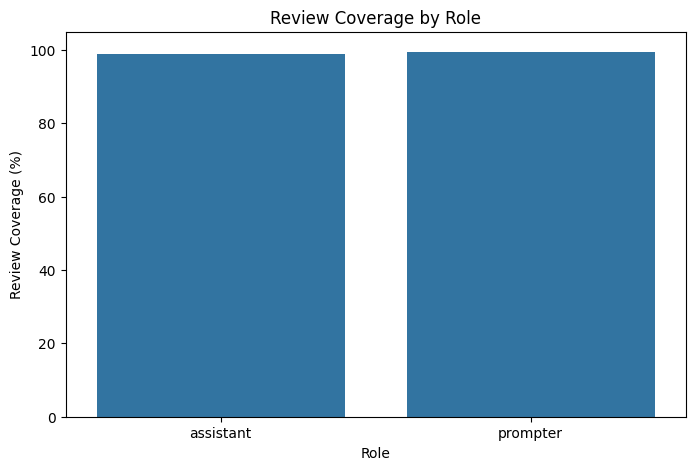

In [24]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=review_role,
    x="role",
    y="review_coverage_percentage"
)

plt.title("Review Coverage by Role")
plt.xlabel("Role")
plt.ylabel("Review Coverage (%)")

plt.ylim(0, 105)

plt.show()

In [25]:
df["message_length"] = df["text"].str.len()

message_length_summary = df["message_length"].describe()

message_length_summary

count    88838.000000
mean       493.759619
std        678.444639
min          1.000000
25%         68.000000
50%        202.000000
75%        679.750000
max       9982.000000
Name: message_length, dtype: float64

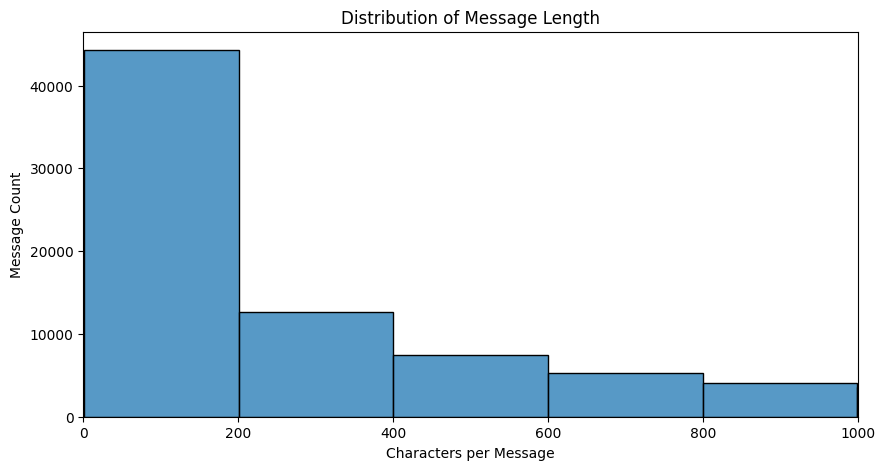

In [26]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["message_length"],
    bins=50
)

plt.title("Distribution of Message Length")
plt.xlabel("Characters per Message")
plt.ylabel("Message Count")

plt.xlim(0, 1000)

plt.show()

In [27]:
role_length = (
    df.groupby("role")["message_length"]
      .agg(["mean", "median", "max"])
      .reset_index()
)

role_length

,role,mean,median,max
0,assistant,716.970737,482.0,9982
1,prompter,119.152547,71.0,9785
